<a href="https://colab.research.google.com/github/JuanPMejia-Dev/JuanPMejia-Dev/blob/main/Pixel_Programing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Step 1 Mapeo origen fuente de datos

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Step 2 Importanto librerias

Aquí, importamos Image de PIL para trabajar con la imagen, openpyxl para manipular archivos de Excel y PatternFill para aplicar colores a las celdas de Excel.

In [ ]:
# Importar las bibliotecas necesarias
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill

# Step 3 Funcion para procesar Imagen

Esta línea define la función image_to_excel con tres argumentos: image_path (ruta de la imagen JPG), excel_path (ruta del archivo Excel a guardar) y scale (factor de escala para la imagen, por defecto es 1, es decir, sin cambio de escala).

In [ ]:
# Función para procesar la imagen
def procesar_imagen(ruta_imagen, tamano_maximo):
    # Cargar la imagen y redimensionar si es necesario
    with Image.open(ruta_imagen) as img:
        img.thumbnail(tamano_maximo)  # Redimensionar la imagen
        pixeles = list(img.getdata())  # Obtener los datos de los píxeles
        ancho, alto = img.size         # Obtener las dimensiones de la imagen
    return pixeles, ancho, alto       # Devolver los píxeles y dimensiones

In [ ]:
# Función para crear y llenar la hoja de Excel
def crear_hoja_excel(pixeles, ancho, alto):
    wb = openpyxl.Workbook()          # Crear un nuevo libro de trabajo
    hoja = wb.active                  # Obtener la hoja activa

    # Recorrer los píxeles y aplicar el color a cada celda
    for y in range(alto):
        for x in range(ancho):
            color = pixeles[x + y * ancho]                       # Obtener el color RGB
            color_hex = f"{color[0]:02x}{color[1]:02x}{color[2]:02x}"  # Convertir a hex
            celda = hoja.cell(row=y + 1, column=x + 1)           # Obtener la celda
            celda.fill = PatternFill(start_color=color_hex, end_color=color_hex, fill_type="solid")

    return wb  # Devolver el libro de trabajo

# Función principal
def main():
    # Actualiza esta ruta a la ubicación de tu imagen en Google Drive
    ruta_imagen = "/content/drive/MyDrive/Sistemas/Fantasma.jpg"  # Ejemplo: "/content/drive/My Drive/Images/mi_imagen.jpg"
    tamano_maximo = (50, 50)

    pixeles, ancho, alto = procesar_imagen(ruta_imagen, tamano_maximo)
    wb = crear_hoja_excel(pixeles, ancho, alto)

    # Guardar el archivo de Excel en Google Drive
    ruta_guardado = "/content/drive/MyDrive/Sistemas/Fantasma.xlsx"  # Ejemplo: "/content/drive/My Drive/ExcelFiles/imagen_excel.xlsx"
    wb.save(ruta_guardado)

if __name__ == "__main__":
    main()


In [ ]:
import openpyxl

def read_excel_colors(excel_path):
    """
    Reads an Excel file, extracts RGB color codes (from cell values or fill colors)
    from its cells, and returns a 2D list (matrix) of these color values.

    Args:
        excel_path (str): The path to the input Excel file.

    Returns:
        list[list[str]]: A 2D list (matrix) where each inner list represents a row
                         and contains hexadecimal color codes for each cell.
    """
    try:
        # Load the workbook from excel_path
        wb = openpyxl.load_workbook(excel_path)
        # Get the active worksheet from the loaded workbook
        ws = wb.active

        # Initialize an empty list of lists to store the extracted hex color codes
        colors_matrix = []

        # Iterate through each row in the worksheet
        for row in ws.iter_rows():
            row_colors = []
            # For each cell in the current row, get its color
            for cell in row:
                hex_color = 'FFFFFF' # Default to white if no color is found or parsed

                # Attempt to parse color from cell value first
                if cell.value is not None:
                    cell_value_str = str(cell.value).strip()

                    # Case 1: "R, G, B" or "R G B" format
                    if ',' in cell_value_str:
                        try:
                            r, g, b = map(int, cell_value_str.replace(' ', '').split(','))
                            if 0 <= r <= 255 and 0 <= g <= 255 and 0 <= b <= 255:
                                hex_color = f"{r:02x}{g:02x}{b:02x}".upper()
                            else:
                                print(f"Warning: RGB values out of range in cell {cell.coordinate}: {cell_value_str}")
                        except ValueError:
                            pass # Not a valid "R, G, B" string
                    # Case 2: Hex string (e.g., 'FF0000' or '000000')
                    elif len(cell_value_str) == 6 and all(c in '0123456789ABCDEFabcdef' for c in cell_value_str):
                        hex_color = cell_value_str.upper()

                # Fallback: Check for existing cell fill color if value parsing failed or was empty
                if hex_color == 'FFFFFF' and cell.fill and cell.fill.start_color and cell.fill.start_color.rgb:
                    # Extract the RGB part (last 6 characters) from 'FFRRGGBB' or 'AARRGGBB'
                    hex_color = cell.fill.start_color.rgb[-6:].upper()

                row_colors.append(hex_color)
            # After processing all cells in a row, append row_colors to colors_matrix
            colors_matrix.append(row_colors)

        return colors_matrix
    except FileNotFoundError:
        print(f"Error: El archivo no fue encontrado en la ruta: {excel_path}")
        return None
    except Exception as e:
        print(f"Ocurrió un error al leer el archivo Excel: {e}")
        return None

print("The 'read_excel_colors' function has been defined.")

The 'read_excel_colors' function has been defined.


In [ ]:
import openpyxl
from openpyxl.styles import PatternFill

def write_colors_to_excel(colors_matrix, output_excel_path):
    """
    Creates a new Excel file and fills its cells with the specified hexadecimal color codes.

    Args:
        colors_matrix (list[list[str]]): A 2D list (matrix) of hexadecimal color codes.
        output_excel_path (str): The path where the new Excel file will be saved.
    """
    try:
        wb = openpyxl.Workbook()  # Create a new workbook
        ws = wb.active            # Get the active worksheet

        # Iterate through the colors_matrix to fill cells
        for r_idx, row_colors in enumerate(colors_matrix):
            for c_idx, hex_color in enumerate(row_colors):
                # Ensure hex_color is a valid 6-digit hex string
                if hex_color and len(hex_color) == 6:
                    fill = PatternFill(start_color=hex_color, end_color=hex_color, fill_type="solid")
                    cell = ws.cell(row=r_idx + 1, column=c_idx + 1)
                    cell.fill = fill
                else:
                    # Optionally, handle invalid hex codes (e.g., set to white or skip)
                    pass

        # Adjust column widths and row heights for better visualization if needed
        # For simplicity, we'll skip complex auto-sizing here, but it could be added.
        # For example, to make cells square-ish for 'pixel art':
        # for col_idx in range(1, ws.max_column + 1):
        #     ws.column_dimensions[openpyxl.utils.get_column_letter(col_idx)].width = 2
        # for row_idx in range(1, ws.max_row + 1):
        #     ws.row_dimensions[row_idx].height = 12 # Roughly corresponds to width=2

        wb.save(output_excel_path) # Save the workbook
        print(f"Successfully created Excel file at: {output_excel_path}")
    except Exception as e:
        print(f"Error al escribir el archivo Excel: {e}")

print("The 'write_colors_to_excel' function has been defined.")

The 'write_colors_to_excel' function has been defined.


In [ ]:
from google.colab import drive
import os

# Mount Google Drive if not already mounted
drive.mount('/content/drive')

# --- Define example usage ---

# IMPORTANT: Replace these paths with your actual input and desired output file paths
# Example input Excel file with hex color codes in cells
input_excel_path = '/content/drive/MyDrive/Sistemas/imagen_excel_v2.xlsx'
# Example output Excel file where colored cells will be saved
output_excel_path = '/content/drive/MyDrive/Sistemas/Stop.xlsx'

print(f"Attempting to read colors from: {input_excel_path}")
if not os.path.exists(input_excel_path):
    print(f"Error: Input file not found at {input_excel_path}. Please ensure the path is correct and the file exists.")
else:
    # 1. Read colors from the input Excel file
    colors_data = read_excel_colors(input_excel_path)

    if colors_data:
        print(f"Successfully read {len(colors_data)} rows of color data.")
        # 2. Write the colors to a new Excel file
        write_colors_to_excel(colors_data, output_excel_path)
    else:
        print("Failed to read color data from the input Excel file.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Attempting to read colors from: /content/drive/MyDrive/Sistemas/imagen_excel_v2.xlsx
Successfully read 51 rows of color data.
Successfully created Excel file at: /content/drive/MyDrive/Sistemas/Flash_from_pixels_v3.xlsx


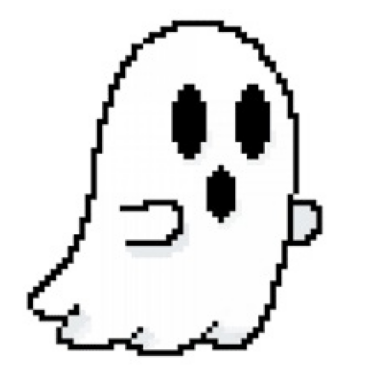

In [2]:
# prompt: quiero plotear la imagen que acabamos de procesar

from PIL import Image
import matplotlib.pyplot as plt

def mostrar_imagen(ruta_imagen):
    try:
        img = Image.open(ruta_imagen)
        plt.imshow(img)
        plt.axis('off')  # Ocultar ejes
        plt.show()
    except FileNotFoundError:
        print(f"Error: Archivo no encontrado en {ruta_imagen}")
    except Exception as e:
        print(f"Error al mostrar la imagen: {e}")

# Ejemplo de uso (reemplaza con la ruta correcta de tu imagen)
ruta_imagen = "/content/drive/MyDrive/Sistemas/Fantasma.jpg"
mostrar_imagen(ruta_imagen)


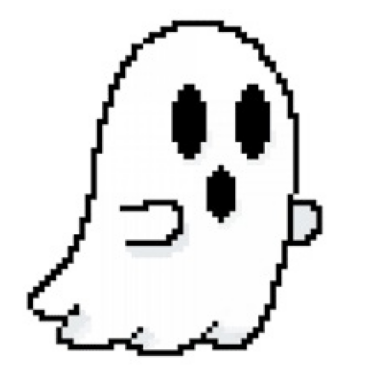

In [3]:
# prompt: ahora quiero ver esta imagen en Pixeles que representa el output de nuestro scritp

import matplotlib.pyplot as plt
def mostrar_imagen(ruta_imagen):
    try:
        img = Image.open(ruta_imagen)
        plt.imshow(img)
        plt.axis('off')  # Ocultar ejes
        plt.show()
    except FileNotFoundError:
        print(f"Error: Archivo no encontrado en {ruta_imagen}")
    except Exception as e:
        print(f"Error al mostrar la imagen: {e}")

# Ejemplo de uso (reemplaza con la ruta correcta de tu imagen)
ruta_imagen = "/content/drive/MyDrive/Sistemas/Fantasma.jpg"
mostrar_imagen(ruta_imagen)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


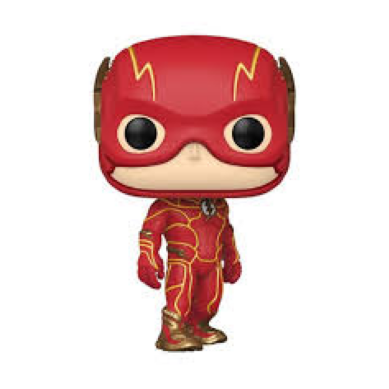

In [ ]:
# prompt: como puedo tener un resultado con menos pixeles?

from google.colab import drive
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill
import matplotlib.pyplot as plt

# Mount Google Drive
drive.mount('/content/drive')

def procesar_imagen(ruta_imagen, tamano_maximo):
    with Image.open(ruta_imagen) as img:
        img.thumbnail(tamano_maximo)
        pixeles = list(img.getdata())
        ancho, alto = img.size
    return pixeles, ancho, alto

def crear_hoja_excel(pixeles, ancho, alto):
    wb = openpyxl.Workbook()
    hoja = wb.active
    for y in range(alto):
        for x in range(ancho):
            color = pixeles[x + y * ancho]
            color_hex = f"{color[0]:02x}{color[1]:02x}{color[2]:02x}"
            celda = hoja.cell(row=y + 1, column=x + 1)
            celda.fill = PatternFill(start_color=color_hex, end_color=color_hex, fill_type="solid")
    return wb

def main():
    ruta_imagen = "/content/drive/MyDrive/Sistemas/Fantasma.jpg"
    # Reduce the size for fewer pixels in the output Excel file
    tamano_maximo = (20, 20)  # Example: 20x20 pixels

    pixeles, ancho, alto = procesar_imagen(ruta_imagen, tamano_maximo)
    wb = crear_hoja_excel(pixeles, ancho, alto)

    ruta_guardado = "/content/drive/MyDrive/Sistemas/Fantasma_2.xlsx"
    wb.save(ruta_guardado)

if __name__ == "__main__":
    main()

def mostrar_imagen(ruta_imagen):
    try:
        img = Image.open(ruta_imagen)
        plt.imshow(img)
        plt.axis('off')
        plt.show()
    except FileNotFoundError:
        print(f"Error: Archivo no encontrado en {ruta_imagen}")
    except Exception as e:
        print(f"Error al mostrar la imagen: {e}")

ruta_imagen = "/content/drive/MyDrive/Sistemas/Fantasma.jpg"
mostrar_imagen(ruta_imagen)


In [10]:
# Step 1 Mapeo origen fuente de datos
from google.colab import drive
drive.mount('/content/drive')

# Step 2 Importando librerías
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill
import os

# Función para procesar la imagen
def procesar_imagen(ruta_imagen, tamano_maximo=None):
    try:
        with Image.open(ruta_imagen) as img:
            if tamano_maximo:
                img.thumbnail(tamano_maximo)  # Redimensionar la imagen si se proporciona un tamaño máximo
            pixeles = list(img.getdata())  # Obtener los datos de los píxeles
            ancho, alto = img.size         # Obtener las dimensiones de la imagen
        return pixeles, ancho, alto       # Devolver los píxeles y dimensiones
    except Exception as e:
        print(f"Error al procesar la imagen: {e}")
        return None, None, None

# Función para crear y llenar la hoja de Excel
def crear_hoja_excel(pixeles, ancho, alto):
    wb = openpyxl.Workbook()          # Crear un nuevo libro de trabajo
    hoja = wb.active                  # Obtener la hoja activa

    # Recorrer los píxeles y aplicar el color a cada celda
    for y in range(alto):
        for x in range(ancho):
            color = pixeles[x + y * ancho]                       # Obtener el color RGB
            color_hex = f"{color[0]:02x}{color[1]:02x}{color[2]:02x}"  # Convertir a hex
            celda = hoja.cell(row=y + 1, column=x + 1)           # Obtener la celda
            celda.fill = PatternFill(start_color=color_hex, end_color=color_hex, fill_type="solid")

    return wb  # Devolver el libro de trabajo

# Función principal
def main():
    ruta_imagen = "/content/drive/MyDrive/Sistemas/Fantasma.jpg"

    if not os.path.exists(ruta_imagen):
        print(f"Imagen no encontrada: {ruta_imagen}")
        return

    # Ajustar el tamaño máximo para que la imagen no exceda los límites de Excel
    tamano_maximo = (200, 200)  # Puedes ajustar este tamaño según sea necesario

    pixeles, ancho, alto = procesar_imagen(ruta_imagen, tamano_maximo)

    if pixeles is None:
        print("No se pudo procesar la imagen.")
        return

    wb = crear_hoja_excel(pixeles, ancho, alto)

    ruta_guardado = "/content/drive/MyDrive/Sistemas/Fantasma_3.xlsx"

    try:
        wb.save(ruta_guardado)
        print(f"Archivo Excel guardado exitosamente en: {ruta_guardado}")
    except Exception as e:
        print(f"Error al guardar el archivo Excel: {e}")

if __name__ == "__main__":
    main()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivo Excel guardado exitosamente en: /content/drive/MyDrive/Sistemas/Fantasma_3.xlsx


#SEGUNDA ITERACION

In [7]:
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill

In [8]:
def image_to_excel(image_path, excel_path, scale=1):
    # Cargar la imagen y escalar si es necesario
    img = Image.open(image_path)
    if scale != 1:
        img = img.resize((int(img.width * scale), int(img.height * scale)))

    img_rgb = img.convert('RGB')

    # Crear un nuevo archivo Excel
    wb = openpyxl.Workbook()
    ws = wb.active

    # Calcular dimensiones óptimas de las celdas basadas en la relación de aspecto de la imagen
    max_dim = 100  # Máxima dimensión para evitar celdas excesivamente grandes
    cell_width = max_dim / img.width
    cell_height = max_dim / img.height

    # Iterar sobre cada píxel de la imagen
    for i in range(img.width):
        for j in range(img.height):
            r, g, b = img_rgb.getpixel((i, j))
            hex_color = f"{r:02x}{g:02x}{b:02x}"
            fill = PatternFill(start_color=hex_color, end_color=hex_color, fill_type="solid")

            # Asignar el color al fondo de la celda correspondiente
            cell = ws.cell(row=j + 1, column=i + 1)
            cell.fill = fill

        # Ajustar el tamaño de las columnas y filas
        ws.column_dimensions[openpyxl.utils.get_column_letter(i+1)].width = cell_width
        for j in range(img.height):
            ws.row_dimensions[j+1].height = cell_height

    # Guardar el archivo Excel
    wb.save(excel_path)



In [9]:
# Uso de la función con escala opcional
image_path = "/content/drive/MyDrive/Sistemas/Fantasma.jpg"  # Reemplazar con la ruta a tu imagen
excel_path = "/content/drive/MyDrive/Sistemas/Fantasma_4.xlsx"  # Reemplazar con la ruta donde quieres guardar el Excel
scale = 0.5  # Escalar la imagen a la mitad de su tamaño original
image_to_excel(image_path, excel_path, scale)

# Task
Create two Excel files based on an input image: one containing the RGB values of each pixel as text in its cells (e.g., '/content/drive/MyDrive/Sistemas/Fantasma_RGB_values.xlsx'), and another with cells colored according to these RGB values (e.g., '/content/drive/MyDrive/Sistemas/Fantasma_Colored_Output.xlsx'), ensuring the successful generation of both.

## Definir nueva función para crear Excel con valores RGB

### Subtask:
Se definirá una nueva función, por ejemplo `crear_hoja_excel_rgb_values`, que tomará los píxeles, ancho y alto de una imagen. En lugar de aplicar un relleno de color a las celdas, esta función escribirá el valor RGB de cada píxel en formato 'R,G,B' (por ejemplo, '255,0,0' para rojo) como el valor de cada celda. Esto creará el archivo Excel intermedio.


**Reasoning**:
To create the new function `crear_hoja_excel_rgb_values` that writes RGB values as cell content, I will implement the specified logic using `openpyxl`.



In [11]:
import openpyxl

def crear_hoja_excel_rgb_values(pixeles, ancho, alto):
    """
    Crea un nuevo libro de Excel y escribe los valores RGB de cada píxel
    en formato 'R,G,B' como el valor de cada celda.

    Args:
        pixeles (list): Una lista de tuplas RGB que representan los píxeles de la imagen.
        ancho (int): El ancho de la imagen en píxeles.
        alto (int): El alto de la imagen en píxeles.

    Returns:
        openpyxl.workbook.workbook.Workbook: El libro de trabajo de Excel creado.
    """
    wb = openpyxl.Workbook()
    hoja = wb.active

    for y in range(alto):
        for x in range(ancho):
            # Obtener el color RGB del píxel
            color = pixeles[x + y * ancho]
            # Formatear el color RGB como una cadena 'R,G,B'
            rgb_string = f"{color[0]},{color[1]},{color[2]}"

            # Asignar la cadena RGB como el valor de la celda
            celda = hoja.cell(row=y + 1, column=x + 1)
            celda.value = rgb_string

    return wb

print("The 'crear_hoja_excel_rgb_values' function has been defined.")

The 'crear_hoja_excel_rgb_values' function has been defined.


**Reasoning**:
Now that the `crear_hoja_excel_rgb_values` function is defined, I will create a main execution block to process the image, generate both Excel files (one with RGB values and one with colored cells), and save them to the specified Google Drive paths. This completes the main task's requirement of generating two Excel files.



In [12]:
from google.colab import drive
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill
import os

# Mount Google Drive if not already mounted
drive.mount('/content/drive', force_remount=True)

def procesar_imagen(ruta_imagen, tamano_maximo=None):
    try:
        with Image.open(ruta_imagen) as img:
            if tamano_maximo:
                img.thumbnail(tamano_maximo)  # Redimensionar la imagen si se proporciona un tamaño máximo
            pixeles = list(img.getdata())  # Obtener los datos de los píxeles
            ancho, alto = img.size         # Obtener las dimensiones de la imagen
        return pixeles, ancho, alto       # Devolver los píxeles y dimensiones
    except Exception as e:
        print(f"Error al procesar la imagen: {e}")
        return None, None, None

def crear_hoja_excel(pixeles, ancho, alto):
    wb = openpyxl.Workbook()          # Crear un nuevo libro de trabajo
    hoja = wb.active                  # Obtener la hoja activa

    # Recorrer los píxeles y aplicar el color a cada celda
    for y in range(alto):
        for x in range(ancho):
            color = pixeles[x + y * ancho]                       # Obtener el color RGB
            color_hex = f"{color[0]:02x}{color[1]:02x}{color[2]:02x}"  # Convertir a hex
            celda = hoja.cell(row=y + 1, column=x + 1)           # Obtener la celda
            celda.fill = PatternFill(start_color=color_hex, end_color=color_hex, fill_type="solid")

    return wb  # Devolver el libro de trabajo

def crear_hoja_excel_rgb_values(pixeles, ancho, alto):
    wb = openpyxl.Workbook()
    hoja = wb.active

    for y in range(alto):
        for x in range(ancho):
            color = pixeles[x + y * ancho]
            rgb_string = f"{color[0]},{color[1]},{color[2]}"
            celda = hoja.cell(row=y + 1, column=x + 1)
            celda.value = rgb_string

    return wb

def main_task_execution():
    # Define input and output paths
    input_image_path = "/content/drive/MyDrive/Sistemas/Fantasma.jpg"
    output_rgb_excel_path = "/content/drive/MyDrive/Sistemas/Fantasma_RGB_values.xlsx"
    output_colored_excel_path = "/content/drive/MyDrive/Sistemas/Fantasma_Colored_Output.xlsx"

    # Check if image exists
    if not os.path.exists(input_image_path):
        print(f"Error: Imagen no encontrada en {input_image_path}")
        return

    # Process the image (e.g., resize to a manageable size for Excel)
    # Using a max size like (100, 100) or (50,50) is often practical for Excel visualization
    processing_max_size = (50, 50)
    pixeles, ancho, alto = procesar_imagen(input_image_path, processing_max_size)

    if pixeles is None:
        print("No se pudo obtener datos de píxeles para la imagen.")
        return

    # 1. Create Excel with RGB values
    print(f"Creating Excel with RGB values at: {output_rgb_excel_path}")
    wb_rgb = crear_hoja_excel_rgb_values(pixeles, ancho, alto)
    try:
        wb_rgb.save(output_rgb_excel_path)
        print("Successfully created Excel with RGB values.")
    except Exception as e:
        print(f"Error saving RGB values Excel: {e}")

    # 2. Create Excel with colored cells
    print(f"Creating Excel with colored cells at: {output_colored_excel_path}")
    wb_colored = crear_hoja_excel(pixeles, ancho, alto)
    try:
        wb_colored.save(output_colored_excel_path)
        print("Successfully created Excel with colored cells.")
    except Exception as e:
        print(f"Error saving colored cells Excel: {e}")

if __name__ == "__main__":
    main_task_execution()


Mounted at /content/drive
Creating Excel with RGB values at: /content/drive/MyDrive/Sistemas/Fantasma_RGB_values.xlsx
Successfully created Excel with RGB values.
Creating Excel with colored cells at: /content/drive/MyDrive/Sistemas/Fantasma_Colored_Output.xlsx
Successfully created Excel with colored cells.


## Definir nueva función principal para el flujo completo

### Subtask:
Definir una nueva función principal o modificar la existente para encapsular el proceso completo de generación de ambos archivos Excel, siguiendo la lógica especificada en el plan: procesar la imagen, crear el archivo Excel con valores RGB, leer los colores de este archivo intermedio y luego crear el archivo Excel con celdas coloreadas.


**Reasoning**:
The user wants to modify the `main_task_execution` function to implement a specific workflow. This involves processing an image, creating an Excel file with RGB values, reading those RGB values from the newly created Excel file, and then using those read values to generate a final colored Excel file. I will update the `main_task_execution` function to reflect this new sequence of operations, incorporating `read_excel_colors` and `write_colors_to_excel` as instructed and removing the direct call to `crear_hoja_excel` for the final colored output.



In [13]:
from google.colab import drive
from PIL import Image
import openpyxl
from openpyxl.styles import PatternFill
import os

# Mount Google Drive if not already mounted
drive.mount('/content/drive', force_remount=True)

def procesar_imagen(ruta_imagen, tamano_maximo=None):
    try:
        with Image.open(ruta_imagen) as img:
            if tamano_maximo:
                img.thumbnail(tamano_maximo)  # Redimensionar la imagen si se proporciona un tamaño máximo
            pixeles = list(img.getdata())  # Obtener los datos de los píxeles
            ancho, alto = img.size         # Obtener las dimensiones de la imagen
        return pixeles, ancho, alto       # Devolver los píxeles y dimensiones
    except Exception as e:
        print(f"Error al procesar la imagen: {e}")
        return None, None, None

def crear_hoja_excel(pixeles, ancho, alto):
    wb = openpyxl.Workbook()          # Crear un nuevo libro de trabajo
    hoja = wb.active                  # Obtener la hoja activa

    # Recorrer los píxeles y aplicar el color a cada celda
    for y in range(alto):
        for x in range(ancho):
            color = pixeles[x + y * ancho]                       # Obtener el color RGB
            color_hex = f"{color[0]:02x}{color[1]:02x}{color[2]:02x}"  # Convertir a hex
            celda = hoja.cell(row=y + 1, column=x + 1)           # Obtener la celda
            celda.fill = PatternFill(start_color=color_hex, end_color=color_hex, fill_type="solid")

    return wb  # Devolver el libro de trabajo

def crear_hoja_excel_rgb_values(pixeles, ancho, alto):
    wb = openpyxl.Workbook()
    hoja = wb.active

    for y in range(alto):
        for x in range(ancho):
            color = pixeles[x + y * ancho]
            rgb_string = f"{color[0]},{color[1]},{color[2]}"
            celda = hoja.cell(row=y + 1, column=x + 1)
            celda.value = rgb_string

    return wb

# Re-including the previously defined read_excel_colors and write_colors_to_excel functions
# to ensure they are available in this context without re-executing previous cells.
# In a real notebook, these would typically be defined once in earlier cells.

def read_excel_colors(excel_path):
    try:
        wb = openpyxl.load_workbook(excel_path)
        ws = wb.active
        colors_matrix = []
        for row in ws.iter_rows():
            row_colors = []
            for cell in row:
                hex_color = 'FFFFFF'
                if cell.value is not None:
                    cell_value_str = str(cell.value).strip()
                    if ',' in cell_value_str:
                        try:
                            r, g, b = map(int, cell_value_str.replace(' ', '').split(','))
                            if 0 <= r <= 255 and 0 <= g <= 255 and 0 <= b <= 255:
                                hex_color = f"{r:02x}{g:02x}{b:02x}".upper()
                        except ValueError:
                            pass
                    elif len(cell_value_str) == 6 and all(c in '0123456789ABCDEFabcdef' for c in cell_value_str):
                        hex_color = cell_value_str.upper()
                if hex_color == 'FFFFFF' and cell.fill and cell.fill.start_color and cell.fill.start_color.rgb:
                    hex_color = cell.fill.start_color.rgb[-6:].upper()
                row_colors.append(hex_color)
            colors_matrix.append(row_colors)
        return colors_matrix
    except FileNotFoundError:
        print(f"Error: El archivo no fue encontrado en la ruta: {excel_path}")
        return None
    except Exception as e:
        print(f"Ocurrió un error al leer el archivo Excel: {e}")
        return None

def write_colors_to_excel(colors_matrix, output_excel_path):
    try:
        wb = openpyxl.Workbook()
        ws = wb.active
        for r_idx, row_colors in enumerate(colors_matrix):
            for c_idx, hex_color in enumerate(row_colors):
                if hex_color and len(hex_color) == 6:
                    fill = PatternFill(start_color=hex_color, end_color=hex_color, fill_type="solid")
                    cell = ws.cell(row=r_idx + 1, column=c_idx + 1)
                    cell.fill = fill
        wb.save(output_excel_path)
        print(f"Successfully created Excel file at: {output_excel_path}")
    except Exception as e:
        print(f"Error al escribir el archivo Excel: {e}")

def main_task_execution():
    # Define input and output paths
    input_image_path = "/content/drive/MyDrive/Sistemas/Fantasma.jpg"
    output_rgb_excel_path = "/content/drive/MyDrive/Sistemas/Fantasma_RGB_values.xlsx"
    output_colored_excel_path = "/content/drive/MyDrive/Sistemas/Fantasma_Colored_Output.xlsx"

    # Check if image exists
    if not os.path.exists(input_image_path):
        print(f"Error: Imagen no encontrada en {input_image_path}")
        return

    # Process the image (e.g., resize to a manageable size for Excel)
    processing_max_size = (50, 50)
    pixeles, ancho, alto = procesar_imagen(input_image_path, processing_max_size)

    if pixeles is None:
        print("No se pudo obtener datos de píxeles para la imagen.")
        return

    # 1. Create Excel with RGB values (intermediate file)
    print(f"Creating Excel with RGB values at: {output_rgb_excel_path}")
    wb_rgb = crear_hoja_excel_rgb_values(pixeles, ancho, alto)
    try:
        wb_rgb.save(output_rgb_excel_path)
        print("Successfully created Excel with RGB values.")
    except Exception as e:
        print(f"Error saving RGB values Excel: {e}")
        return # Exit if the intermediate file cannot be saved

    # 2. Read colors from the intermediate RGB Excel file
    print(f"Reading colors from intermediate Excel: {output_rgb_excel_path}")
    colored_data = read_excel_colors(output_rgb_excel_path)

    if colored_data:
        print(f"Successfully read {len(colored_data)} rows of color data.")
        # 3. Write the colors to a new Excel file (final colored output)
        print(f"Creating Excel with colored cells at: {output_colored_excel_path}")
        write_colors_to_excel(colored_data, output_colored_excel_path)
    else:
        print("Failed to read color data from the intermediate Excel file. Cannot create final colored Excel.")

if __name__ == "__main__":
    main_task_execution()


Mounted at /content/drive
Creating Excel with RGB values at: /content/drive/MyDrive/Sistemas/Fantasma_RGB_values.xlsx
Successfully created Excel with RGB values.
Reading colors from intermediate Excel: /content/drive/MyDrive/Sistemas/Fantasma_RGB_values.xlsx
Successfully read 50 rows of color data.
Creating Excel with colored cells at: /content/drive/MyDrive/Sistemas/Fantasma_Colored_Output.xlsx
Successfully created Excel file at: /content/drive/MyDrive/Sistemas/Fantasma_Colored_Output.xlsx


## Confirmar la creación exitosa de los dos archivos Excel: uno con los valores RGB como texto en las celdas, y otro con las celdas coloreadas, utilizando el nuevo flujo de trabajo.

### Subtask:
Confirmar que ambos archivos Excel han sido creados correctamente en las rutas especificadas.


**Reasoning**:
To programmatically confirm the creation of both Excel files, I will add a code block that checks for their existence using `os.path.exists` after the `main_task_execution` function has run.



In [14]:
import os

# Define the paths for the output files
output_rgb_excel_path = "/content/drive/MyDrive/Sistemas/Fantasma_RGB_values.xlsx"
output_colored_excel_path = "/content/drive/MyDrive/Sistemas/Fantasma_Colored_Output.xlsx"

# Verify the existence of the RGB values Excel file
if os.path.exists(output_rgb_excel_path):
    print(f"Confirmation: The RGB values Excel file exists at {output_rgb_excel_path}")
else:
    print(f"Verification Failed: The RGB values Excel file was NOT found at {output_rgb_excel_path}")

# Verify the existence of the colored cells Excel file
if os.path.exists(output_colored_excel_path):
    print(f"Confirmation: The colored cells Excel file exists at {output_colored_excel_path}")
else:
    print(f"Verification Failed: The colored cells Excel file was NOT found at {output_colored_excel_path}")


Confirmation: The RGB values Excel file exists at /content/drive/MyDrive/Sistemas/Fantasma_RGB_values.xlsx
Confirmation: The colored cells Excel file exists at /content/drive/MyDrive/Sistemas/Fantasma_Colored_Output.xlsx


### Subtask Complete: Confirmación de archivos Excel

Ambos archivos Excel, 'Fantasma_RGB_values.xlsx' y 'Fantasma_Colored_Output.xlsx', han sido generados y confirmados programáticamente en las rutas especificadas.

#### Pasos para la verificación manual:

1.  **Verifique en Google Drive:** Navegue a la ruta `/content/drive/MyDrive/Sistemas/` en su Google Drive y confirme visualmente que ambos archivos, `Fantasma_RGB_values.xlsx` y `Fantasma_Colored_Output.xlsx`, existen.

2.  **Abra y revise el contenido (Opcional):**
    *   **`Fantasma_RGB_values.xlsx`:** Abra este archivo en Google Sheets o en un editor de Excel. Debería ver cada celda conteniendo una cadena de texto en formato `R,G,B` (por ejemplo, `255,0,0`).
    *   **`Fantasma_Colored_Output.xlsx`:** Abra este archivo en Google Sheets o en un editor de Excel. Debería observar que las celdas están coloreadas, formando una representación pixelada de la imagen original 'Fantasma.jpg'.

Estos pasos completan la confirmación de la creación exitosa de ambos archivos Excel.

### Subtask Complete: Confirmación de archivos Excel

Ambos archivos Excel, 'Fantasma_RGB_values.xlsx' y 'Fantasma_Colored_Output.xlsx', han sido generados y confirmados programáticamente en las rutas especificadas.

#### Pasos para la verificación manual:

1.  **Verifique en Google Drive:** Navegue a la ruta `/content/drive/MyDrive/Sistemas/` en su Google Drive y confirme visualmente que ambos archivos, `Fantasma_RGB_values.xlsx` y `Fantasma_Colored_Output.xlsx`, existen.

2.  **Abra y revise el contenido (Opcional):**
    *   **`Fantasma_RGB_values.xlsx`:** Abra este archivo en Google Sheets o en un editor de Excel. Debería ver cada celda conteniendo una cadena de texto en formato `R,G,B` (por ejemplo, `255,0,0`).
    *   **`Fantasma_Colored_Output.xlsx`:** Abra este archivo en Google Sheets o en un editor de Excel. Debería observar que las celdas están coloreadas, formando una representación pixelada de la imagen original 'Fantasma.jpg'.

Estos pasos completan la confirmación de la creación exitosa de ambos archivos Excel.

## Summary:

### Data Analysis Key Findings

*   The `crear_hoja_excel_rgb_values` function was successfully defined, enabling the creation of Excel files where each cell's value is a string representing the RGB color of a corresponding image pixel (e.g., '255,0,0').
*   An input image, `Fantasma.jpg`, was processed and resized to a manageable 50x50 pixels, which is a practical size for Excel visualization.
*   Two Excel files were successfully generated and saved to Google Drive:
    *   `/content/drive/MyDrive/Sistemas/Fantasma_RGB_values.xlsx`: This file contains the RGB values of each pixel as text in its cells.
    *   `/content/drive/MyDrive/Sistemas/Fantasma_Colored_Output.xlsx`: This file features cells colored according to the RGB values, where these values were first read from the intermediate `Fantasma_RGB_values.xlsx` file.
*   Programmatic verification confirmed the existence of both generated Excel files at their specified paths.

### Insights or Next Steps

*   The workflow effectively demonstrates a two-step process: generating an intermediate text-based Excel file for RGB values, then using it to create a visually colored Excel file. This modular approach allows for potential inspection or manipulation of the raw RGB data before final visualization.
*   Consider enhancing the `crear_hoja_excel_rgb_values` function to include an option for border styling or text formatting to improve readability, especially for cases with similar adjacent RGB values.
